# Computer Vision with MediaPipe

## Learning Objectives
* Learn how to do simple object detection with MediaPipe


In [ ]:
# Note: for this session we use a GPU on an older version of Colab
# %%time
!pip install mediapipe mediapipe-model-maker

In [ ]:
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import cv2  # OpenCV for image manipulation (drawing boxes)
import matplotlib.pyplot as plt # Matplotlib for displaying the result

In [ ]:
# Download a model
# path = kagglehub.model_download("tensorflow/efficientdet/tfLite/lite0-detection-metadata")
# path = kagglehub.model_download("tensorflow/mobilenet-v2/tfLite/1-0-224-metadata")
!wget https://storage.googleapis.com/mediapipe-models/object_detector/ssd_mobilenet_v2/float16/latest/ssd_mobilenet_v2.tflite
!ls

--2025-12-04 09:03:46--  https://storage.googleapis.com/mediapipe-models/object_detector/ssd_mobilenet_v2/float16/latest/ssd_mobilenet_v2.tflite
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.130.207, 74.125.68.207, 74.125.24.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.130.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5918749 (5.6M) [application/octet-stream]
Saving to: ‘ssd_mobilenet_v2.tflite’

ssd_mobilenet_v2.tf 100%[===================>]   5.64M  3.77MB/s    in 1.5s    

2025-12-04 09:03:49 (3.77 MB/s) - ‘ssd_mobilenet_v2.tflite’ saved [5918749/5918749]

sample_data  ssd_mobilenet_v2.tflite


In [ ]:
# Download some random example images
!wget -Oq demo.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/0/02/Family_lunch_in_Uganda.jpg/960px-Family_lunch_in_Uganda.jpg
!wget -Oq demo2.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/9/99/Posse_Senadores_2019_%2833076008488%29.jpg/960px-Posse_Senadores_2019_%2833076008488%29.jpg

# Download a real dataset of tumors in a brain (coco format) https://www.kaggle.com/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation/data
!curl -q -L -o brain-tumor-image-dataset-semantic-segmentation.zip\
  https://www.kaggle.com/api/v1/datasets/download/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
!unzip -q brain-tumor-image-dataset-semantic-segmentation.zip
!ls

--2025-12-04 09:03:49--  https://upload.wikimedia.org/wikipedia/commons/thumb/0/02/Family_lunch_in_Uganda.jpg/960px-Family_lunch_in_Uganda.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 136934 (134K) [image/jpeg]
Saving to: ‘demo.jpg’

demo.jpg            100%[===================>] 133.72K  --.-KB/s    in 0.004s  

2025-12-04 09:03:49 (33.4 MB/s) - ‘demo.jpg’ saved [136934/136934]

--2025-12-04 09:03:49--  https://upload.wikimedia.org/wikipedia/commons/thumb/9/99/Posse_Senadores_2019_%2833076008488%29.jpg/960px-Posse_Senadores_2019_%2833076008488%29.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK

In [ ]:
# Model Path
DETECTION_MODEL_PATH = '/content/ssd_mobilenet_v2.tflite'

# Load an image
mp_image = mp.Image.create_from_file('demo2.jpg')
# mp_image = mp.Image.create_from_file("/content/train/images/1002_jpg.rf.57d3a8702704771f3315b19aac1aaae7.jpg")

In [ ]:

# --- Object Detection ---

# 1. Set the Object Detection options
options = vision.ObjectDetectorOptions(
    base_options=python.BaseOptions(model_asset_path=DETECTION_MODEL_PATH),
    running_mode=vision.RunningMode.IMAGE,
    max_results=20, # How many objects to show
    score_threshold=0.3 # Only show objects with >30% confidence
)

# 2. Initialize the Model
detector = vision.ObjectDetector.create_from_options(options)

# 3. Run the Task
detection_result = detector.detect(mp_image)

# 4. Process and Report Results (Text)
detections = detection_result.detections
if detections:
    for i, detection in enumerate(detections):
        bbox = detection.bounding_box
        category = detection.categories[0]
        print(f"  {i+1}. {category.category_name} ({category.score:.2f})")
        print(f"     BBox: x={bbox.origin_x}, y={bbox.origin_y}, w={bbox.width}, h={bbox.height}")


else:
    print("No objects detected above the threshold.")


  1. person (0.67)
     BBox: x=498, y=284, w=110, h=193
  2. person (0.66)
     BBox: x=476, y=390, w=185, h=251
  3. person (0.57)
     BBox: x=259, y=386, w=158, h=244
  4. tv (0.53)
     BBox: x=2, y=389, w=89, h=123
  5. keyboard (0.51)
     BBox: x=8, y=521, w=152, h=60
  6. tv (0.44)
     BBox: x=451, y=274, w=75, h=55
  7. person (0.44)
     BBox: x=225, y=308, w=68, h=66
  8. person (0.42)
     BBox: x=623, y=482, w=104, h=154
  9. tv (0.35)
     BBox: x=75, y=381, w=161, h=128
  10. chair (0.35)
     BBox: x=143, y=490, w=146, h=150
  11. chair (0.34)
     BBox: x=402, y=407, w=64, h=120
  12. person (0.32)
     BBox: x=879, y=571, w=81, h=69
  13. person (0.30)
     BBox: x=137, y=346, w=70, h=36


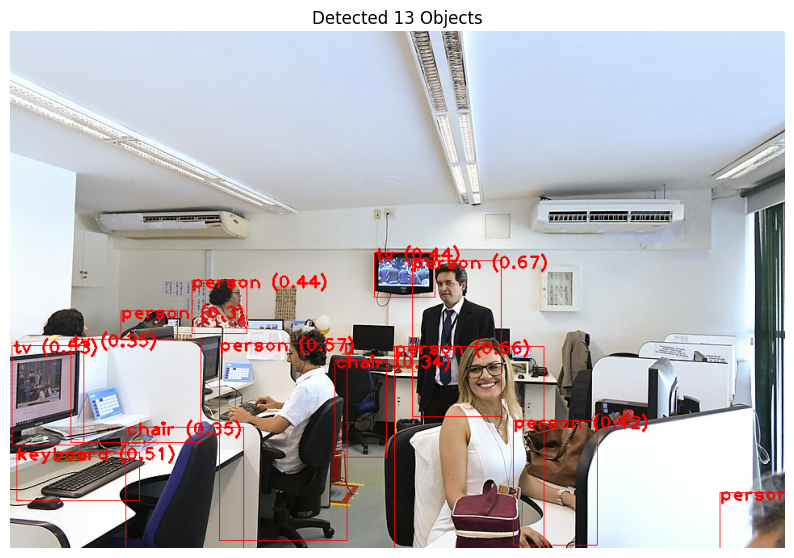

In [ ]:
# Visualisation Helper
def visualise(image, detection_result):
    """
    Draws bounding boxes and labels on the image for diagnostic purposes.
    """
    # Convert the MediaPipe image to a NumPy array (RGB) so we can draw on it
    annotated_image = np.copy(image.numpy_view())

    # Loop through all detections
    for detection in detection_result.detections:
        # Get the bounding box coordinates
        bbox = detection.bounding_box
        start_point = (bbox.origin_x, bbox.origin_y)
        end_point = (bbox.origin_x + bbox.width, bbox.origin_y + bbox.height)

        # Get the category name and score
        category = detection.categories[0]
        category_name = category.category_name
        probability = round(category.score, 2)
        result_text = f"{category_name} ({probability})"

        # Draw the rectangle (Red color, thickness 3)
        cv2.rectangle(annotated_image, start_point, end_point, (255, 0, 0), 1)

        # Draw the label text just inside the box
        text_location = (bbox.origin_x, bbox.origin_y + 10)
        cv2.putText(annotated_image, result_text, text_location,
                    cv2.FONT_HERSHEY_PLAIN, 1.5, (255, 0, 0), 2)

    return annotated_image

# --- 5. Visualization (Graphical) ---
annotated_image = visualise(mp_image, detection_result)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_image)
plt.axis('off') # Hide axes for cleaner look
plt.title(f"Detected {len(detections)} Objects")
plt.show()

## But what about our data!?
Most CV models are trained on something like ImageNet or COCO. We must fine-tune the models on new classes of data so it knows what we want it to find.

In [ ]:
# Wrangle the data into the right structure
!mkdir train/images
!mv train/*.jpg train/images

!mkdir valid/images
!mv valid/*.jpg valid/images

!jq '.categories |= map(.id += 1) | .annotations |= map(.category_id += 1)' train/_annotations.coco.json > train/labels.json
!jq '.categories |= map(.id += 1) | .annotations |= map(.category_id += 1)' valid/_annotations.coco.json > valid/labels.json

In [ ]:
from mediapipe_model_maker import object_detector
import os

from matplotlib import patches, text, patheffects
from collections import defaultdict
import math
import json

/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
train_annotation_file = 'train/labels.json'
val_annotation_file = 'valid/labels.json'

# The '_dataset_path' should point to the folder containing your 'train' and 'validation' folders
train_dataset_path = 'train'
validation_dataset_path = 'valid'

In [ ]:
# LOAD TRAINING DATA (COCO)
# Note: 'images_dir' is the subfolder inside 'train_dataset_path'
#       'annotation_filename' is the specific json file inside 'train_dataset_path'
train_data = object_detector.Dataset.from_coco_folder(
    train_dataset_path
)

# LOAD VALIDATION DATA (COCO)
validation_data = object_detector.Dataset.from_coco_folder(
    validation_dataset_path
)

print("train_data size: ", train_data.size)
print("validation_data size: ", validation_data.size)

train_data size:  1501
validation_data size:  429


In [ ]:
# 2. Configure the Model (Same as before)
spec = object_detector.SupportedModels.MOBILENET_V2
hparams = object_detector.HParams(
    batch_size=64,
    epochs=1, # For demo purposes
    learning_rate=0.3
)
options = object_detector.ObjectDetectorOptions(
    supported_model=spec,
    hparams=hparams
)

In [ ]:
# 3. Create and Train
%%time
print("Starting training...")
model = object_detector.ObjectDetector.create(
    train_data=train_data,
    validation_data=validation_data,
    options=options
)

Starting training...


/usr/local/lib/python3.11/dist-packages/keras/src/engine/functional.py:642: UserWarning: Input dict contained keys ['6'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


Model: "retina_net_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobile_net (MobileNet)      {'2': (None, 64, 64, 24   2257984   
                             ),                                  
                              '3': (None, 32, 32, 32             
                             ),                                  
                              '4': (None, 16, 16, 96             
                             ),                                  
                              '5': (None, 8, 8, 320)             
                             , '6': (None, 8, 8, 128             
                             0)}                                 
                                                                 
 fpn (FPN)                   {'5': (None, 8, 8, 128)   149056    
                             , '4': (None, 16, 16, 1             
                             28),                 

/usr/local/lib/python3.11/dist-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


23/23 [==============================] - 542s 22s/step - total_loss: 2.4932 - cls_loss: 2.0546 - box_loss: 0.0077 - model_loss: 2.4375 - val_total_loss: 5.5039 - val_cls_loss: 1.8335 - val_box_loss: 0.0723 - val_model_loss: 5.4476
Epoch 2/5
23/23 [==============================] - 506s 22s/step - total_loss: 0.7976 - cls_loss: 0.5118 - box_loss: 0.0046 - model_loss: 0.7410 - val_total_loss: 2.4356 - val_cls_loss: 1.1564 - val_box_loss: 0.0244 - val_model_loss: 2.3788
Epoch 3/5
23/23 [==============================] - 505s 22s/step - total_loss: 0.5739 - cls_loss: 0.3483 - box_loss: 0.0034 - model_loss: 0.5171 - val_total_loss: 1.0552 - val_cls_loss: 0.6259 - val_box_loss: 0.0074 - val_model_loss: 0.9983
Epoch 4/5
23/23 [==============================] - 492s 21s/step - total_loss: 0.4516 - cls_loss: 0.2724 - box_loss: 0.0024 - model_loss: 0.3947 - val_total_loss: 0.8178 - val_cls_loss: 0.5247 - val_box_loss: 0.0047 - val_model_loss: 0.7609
Epoch 5/5
23/23 [=============================

In [ ]:
# 4. Evaluate
loss, coco_metrics = model.evaluate(validation_data, batch_size=4)
print(f"Validation Loss: {loss}")
print(f"COCO Metrics: {coco_metrics}")

108/108 [==============================] - 23s 212ms/step - total_loss: 0.7561 - cls_loss: 0.4663 - box_loss: 0.0047 - model_loss: 0.6991


/usr/local/lib/python3.11/dist-packages/keras/src/engine/functional.py:642: UserWarning: Input dict contained keys ['6'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


creating index...
index created!
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.28s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.332
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.681
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.292
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.288
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.370
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.406
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.474
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.476
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 

TypeError: ObjectDetector.export_model() got an unexpected keyword argument 'export_dir'

In [ ]:
# 4. Export the model!
model.export_model(model_name="brain.tflite")

Exporting a floating point model


/usr/local/lib/python3.11/dist-packages/keras/src/engine/functional.py:642: UserWarning: Input dict contained keys ['6'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)
/usr/local/lib/python3.11/dist-packages/keras/src/engine/functional.py:642: UserWarning: Input dict contained keys ['6'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


In [ ]:
# Then run the inference again on our trained model!
inf_image = mp.Image.create_from_file("/content/train/images/1997_jpg.rf.57e306420710246d04c0d5c26e6496c6.jpg")

# 1. Set the Object Detection options
options = vision.ObjectDetectorOptions(
    base_options=python.BaseOptions(model_asset_path='./brain.tflite'),
    running_mode=vision.RunningMode.IMAGE,
    max_results=20,
    score_threshold=0.3
)

# 2. Initialize the Model
detector = vision.ObjectDetector.create_from_options(options)

# 3. Run the Task
detection_result = detector.detect(inf_image)

# 4. Process and Report Results (Text)
detections = detection_result.detections